In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
housing = fetch_california_housing()

In [4]:
print(type(housing))

<class 'sklearn.utils._bunch.Bunch'>


In [5]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
X,y = fetch_california_housing(return_X_y=True)

In [7]:
X.shape

(20640, 8)

In [8]:
y.shape

(20640,)

In [9]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [10]:
housing = fetch_california_housing()

df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y

In [11]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
df.shape

(20640, 9)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [14]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [15]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

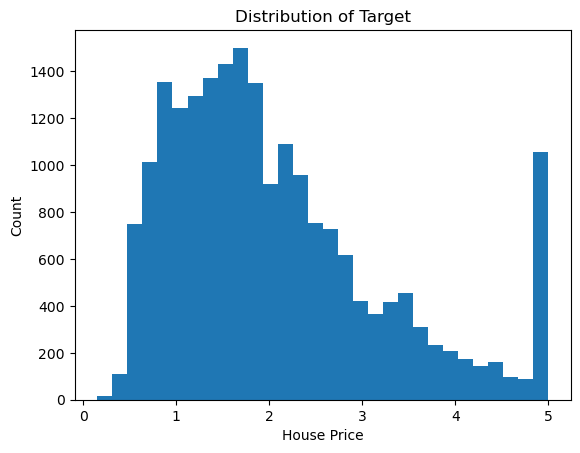

In [17]:
plt.hist(df["MedHouseVal"], bins=30)
plt.xlabel("House Price")
plt.ylabel("Count")
plt.title("Distribution of Target")
plt.show()

In [18]:
X = df.iloc[:, 0:8]
y = df.iloc[:, -1]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
class GDRegressor:
    def __init__(self, lr = 0.01, epochs=1000):
        self.coef_ = None
        self.intercept_ = None
        self.lr = lr
        self.epochs = epochs
        self.losses = []

    def fit(self, X_train, y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            y_hat = np.dot(X_train, self.coef_)+self.intercept_
        
            intercept_der = -2*np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (intercept_der * self.lr)

            coef_der = -2*np.dot((y_train - y_hat), X_train) / X_train.shape[0]
            self.coef_ = self.coef_ - (coef_der * self.lr)

            loss = np.mean((y_train - y_hat) ** 2)
            self.losses.append(loss)
            if i % 100 == 0:
                print(f"Epoch {i}: Loss = {loss:.4f}")

    def predict(self, X_test):
         return np.dot(X_test, self.coef_) + self.intercept_

In [23]:
gdr = GDRegressor(0.01,2000)

In [24]:
gdr.fit(X_train, y_train)

Epoch 0: Loss = 10.9924
Epoch 100: Loss = 1.0557
Epoch 200: Loss = 0.8071
Epoch 300: Loss = 0.7339
Epoch 400: Loss = 0.6829
Epoch 500: Loss = 0.6447
Epoch 600: Loss = 0.6159
Epoch 700: Loss = 0.5940
Epoch 800: Loss = 0.5773
Epoch 900: Loss = 0.5645
Epoch 1000: Loss = 0.5546
Epoch 1100: Loss = 0.5469
Epoch 1200: Loss = 0.5410
Epoch 1300: Loss = 0.5363
Epoch 1400: Loss = 0.5327
Epoch 1500: Loss = 0.5298
Epoch 1600: Loss = 0.5275
Epoch 1700: Loss = 0.5256
Epoch 1800: Loss = 0.5242
Epoch 1900: Loss = 0.5230


In [25]:
y_pred = gdr.predict(X_test)

In [26]:
print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

R2 : 0.5703369242918208
MAE : 0.5330151715937012
MSE : 0.5630343520265975


In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
lr = LinearRegression()

In [29]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_p = lr.predict(X_test)

In [31]:
print("R2 :", r2_score(y_test, y_p))
print("MAE :", mean_absolute_error(y_test, y_p))
print("MSE :", mean_squared_error(y_test, y_p))

R2 : 0.575787706032451
MAE : 0.5332001304956565
MSE : 0.5558915986952442


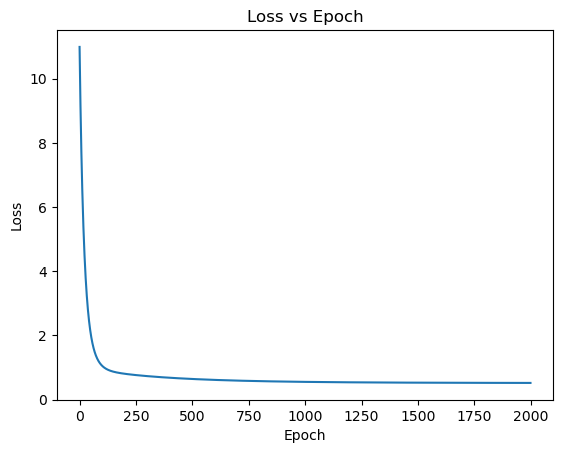

In [33]:
plt.plot(gdr.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()

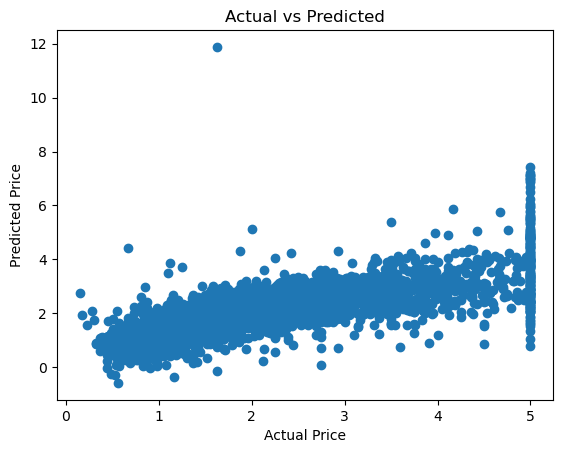

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

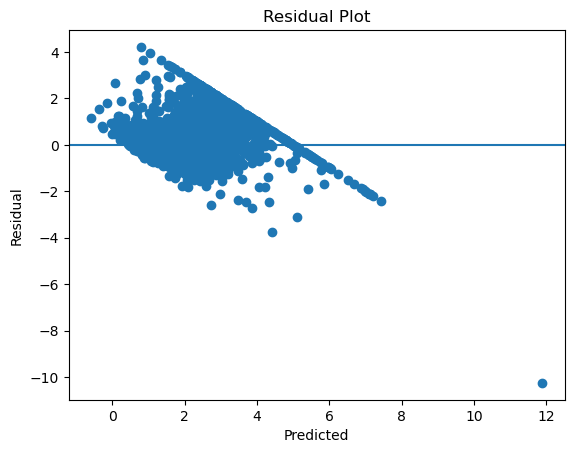

In [39]:
residual = y_test - y_pred
plt.scatter(y_pred, residual)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

| Model | R2 Score | MAE | MSE |
|---|---:|---:|---:|
| Gradient Descent (Scratch) | 0.5514 | 0.533 | 0.563 |
| Linear Regression (Scikit-learn) | 0.5758 | 0.5332 | 0.5559 |